In [22]:
# ============================================================
# PHASE 4 — MODÉLISATION PRÉDICTIVE & INTERPRÉTABILITÉ
# Objectif : Prédire si une commande aura un avis négatif (score ≤ 2)
# ============================================================

# ── 0. IMPORTS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import shap
shap.initjs()

sns.set_theme(style='whitegrid')

In [23]:
# ── 1. CHARGEMENT DIRECT DEPUIS LES CSV RAW (évite master_table.csv trop lourd) ──

import pandas as pd
import numpy as np

# Chargement des fichiers source
orders         = pd.read_csv('../data/raw/olist_orders_dataset.csv',
                             parse_dates=['order_purchase_timestamp',
                                          'order_delivered_customer_date',
                                          'order_estimated_delivery_date'])
order_items    = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/raw/olist_order_payments_dataset.csv')
order_reviews  = pd.read_csv('../data/raw/olist_order_reviews_dataset.csv')[
                     ['order_id', 'review_score']]          # colonnes utiles seulement
customers      = pd.read_csv('../data/raw/olist_customers_dataset.csv')[
                     ['customer_id', 'customer_unique_id', 'customer_state']]
products       = pd.read_csv('../data/raw/olist_products_dataset.csv')[
                     ['product_id', 'product_category_name']]
category_tr    = pd.read_csv('../data/raw/product_category_name_translation.csv')

# Agrégation des payments par commande (évite les doublons de lignes)
payments_agg = (order_payments
                .groupby('order_id')
                .agg(payment_value=('payment_value','sum'),
                     payment_installments=('payment_installments','max'),
                     payment_type=('payment_type','first'))
                .reset_index())

# Agrégation des items par commande
items_agg = (order_items
             .groupby('order_id')
             .agg(price=('price','sum'),
                  freight_value=('freight_value','sum'),
                  product_id=('product_id','first'))
             .reset_index())

# Un seul avis par commande
reviews_agg = (order_reviews
               .groupby('order_id')['review_score']
               .mean()
               .reset_index())

# Jointure légère — uniquement les colonnes nécessaires
df = (orders[['order_id','customer_id',
              'order_purchase_timestamp',
              'order_delivered_customer_date',
              'order_estimated_delivery_date',
              'order_status']]
      .merge(items_agg,    on='order_id',    how='left')
      .merge(payments_agg, on='order_id',    how='left')
      .merge(reviews_agg,  on='order_id',    how='left')
      .merge(customers,    on='customer_id', how='left')
      .merge(products,     on='product_id',  how='left')
      .merge(category_tr,  on='product_category_name', how='left')
)

rfm = pd.read_csv('../data/processed/rfm_clusters.csv')

print(f"✅ df shape     : {df.shape}")
print(f"✅ rfm shape    : {rfm.shape}")
print(f"   RAM estimée  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head(3)

✅ df shape     : (99441, 17)
✅ rfm shape    : (96096, 5)
   RAM estimée  : 74.7 MB


,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_status,price,freight_value,product_id,payment_value,payment_installments,payment_type,review_score,customer_unique_id,customer_state,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,delivered,29.99,8.72,87285b34884572647811a353c7ac498a,38.71,1.0,credit_card,4.0,7c396fd4830fd04220f754e42b4e5bff,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,delivered,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,141.46,1.0,boleto,4.0,af07308b275d755c9edb36a90c618231,BA,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,delivered,159.90,19.22,aa4383b373c6aca5d8797843e5594415,179.12,3.0,credit_card,5.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,automotivo,auto


In [24]:
# ── 2. FEATURE ENGINEERING ──────────────────────────────────

# TARGET
df['target'] = (df['review_score'] <= 2).astype(int)
print(f"Taux d'avis négatifs : {df['target'].mean()*100:.1f}%")

# Livraison
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']    = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late']       = (df['delay_days'] > 0).astype(int)

# Temporel
df['order_hour']     = df['order_purchase_timestamp'].dt.hour
df['order_dow']      = df['order_purchase_timestamp'].dt.dayofweek
df['order_month_nb'] = df['order_purchase_timestamp'].dt.month

# Revenue
df['revenue']        = df['price'].fillna(0) + df['freight_value'].fillna(0)
df['freight_ratio']  = df['freight_value'] / (df['price'] + 1e-6)

# Encodage
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['customer_state_enc'] = le.fit_transform(df['customer_state'].fillna('unknown'))

top_cats = df['product_category_name_english'].value_counts().head(20).index
df['category_top20'] = df['product_category_name_english'].apply(
    lambda x: x if x in top_cats else 'other')
df['category_enc']      = le.fit_transform(df['category_top20'].fillna('unknown'))
df['payment_type_enc']  = le.fit_transform(df['payment_type'].fillna('unknown'))

# Merge RFM
df = df.merge(rfm[['customer_unique_id','recency','frequency','monetary','cluster']],
              on='customer_unique_id', how='left')

# Features finales
FEATURES = [
    'price', 'freight_value', 'freight_ratio', 'revenue',
    'delivery_days', 'delay_days', 'is_late',
    'order_hour', 'order_dow', 'order_month_nb',
    'customer_state_enc', 'category_enc', 'payment_type_enc',
    'payment_installments',
    'recency', 'frequency', 'monetary', 'cluster'
]

df_model = df[FEATURES + ['target']].dropna()
print(f"Dataset modélisation : {df_model.shape}")
print(f"Taux positifs        : {df_model['target'].mean()*100:.1f}%")

# Libérer la mémoire
del df, orders, order_items, order_payments, order_reviews
del customers, products, category_tr, items_agg, payments_agg, reviews_agg
import gc; gc.collect()
print("✅ Mémoire libérée")

Taux d'avis négatifs : 14.5%
Dataset modélisation : (96475, 19)
Taux positifs        : 12.7%
✅ Mémoire libérée


In [25]:
# ── 3. SPLIT — on réduit le dataset pour économiser la RAM ──

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X = df_model[FEATURES]
y = df_model['target']

# ✅ On garde 30% du dataset pour travailler en mémoire réduite
X_small, _, y_small, _ = train_test_split(X, y, train_size=0.3,
                                           random_state=42, stratify=y)

X_train, X_test, y_train, y_test = train_test_split(X_small, y_small,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=y_small)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Taux positifs — Train : {y_train.mean():.3f}  |  Test : {y_test.mean():.3f}")

Train : (23153, 18)  |  Test : (5789, 18)
Taux positifs — Train : 0.127  |  Test : 0.127


In [26]:
# ── 4. MODÈLES — paramètres allégés ─────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,   # ✅ réduit de 200 → 100
        max_depth=8,        # ✅ réduit de 10 → 8
        class_weight='balanced',
        random_state=42,
        n_jobs=1            # ✅ pas de parallélisme
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,   # ✅ réduit de 300 → 100
        max_depth=5,        # ✅ réduit de 6 → 5
        learning_rate=0.1,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=1,           # ✅ pas de parallélisme
        tree_method='hist'  # ✅ plus rapide et moins gourmand
    )
}

print("✅ 3 modèles définis (mode mémoire réduite)")

✅ 3 modèles définis (mode mémoire réduite)


In [27]:
# ── 5. VALIDATION CROISÉE — n_jobs=1 ────────────────────────

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # ✅ 3 folds au lieu de 5
cv_results = {}

for name, model in models.items():
    print(f"⏳ CV en cours : {name}...")
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1            # ✅ séquentiel, pas de fork mémoire
    )
    cv_results[name] = scores
    print(f"   ✅ {name:25s} AUC-ROC : {scores.mean():.4f} ± {scores.std():.4f}")

⏳ CV en cours : Logistic Regression...
   ✅ Logistic Regression       AUC-ROC : 0.7126 ± 0.0047
⏳ CV en cours : Random Forest...
   ✅ Random Forest             AUC-ROC : 0.7186 ± 0.0055
⏳ CV en cours : XGBoost...
   ✅ XGBoost                   AUC-ROC : 0.7142 ± 0.0035


In [28]:
# ── 6. ENTRAÎNEMENT FINAL ────────────────────────────────────

from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score)

results = {}

for name, model in models.items():
    print(f"⏳ Entraînement : {name}...")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    ap  = average_precision_score(y_test, y_proba)

    results[name] = {
        'model': model, 'y_pred': y_pred,
        'y_proba': y_proba, 'auc': auc, 'ap': ap
    }
    print(f"   ✅ AUC-ROC = {auc:.4f}  |  Avg Precision = {ap:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Positif','Négatif']))

⏳ Entraînement : Logistic Regression...
   ✅ AUC-ROC = 0.7071  |  Avg Precision = 0.3972
              precision    recall  f1-score   support

     Positif       0.92      0.87      0.89      5055
     Négatif       0.33      0.45      0.38       734

    accuracy                           0.82      5789
   macro avg       0.62      0.66      0.64      5789
weighted avg       0.84      0.82      0.83      5789

⏳ Entraînement : Random Forest...
   ✅ AUC-ROC = 0.7298  |  Avg Precision = 0.4296
              precision    recall  f1-score   support

     Positif       0.92      0.89      0.91      5055
     Négatif       0.38      0.45      0.41       734

    accuracy                           0.84      5789
   macro avg       0.65      0.67      0.66      5789
weighted avg       0.85      0.84      0.84      5789

⏳ Entraînement : XGBoost...
   ✅ AUC-ROC = 0.7252  |  Avg Precision = 0.4333
              precision    recall  f1-score   support

     Positif       0.92      0.86      0.8

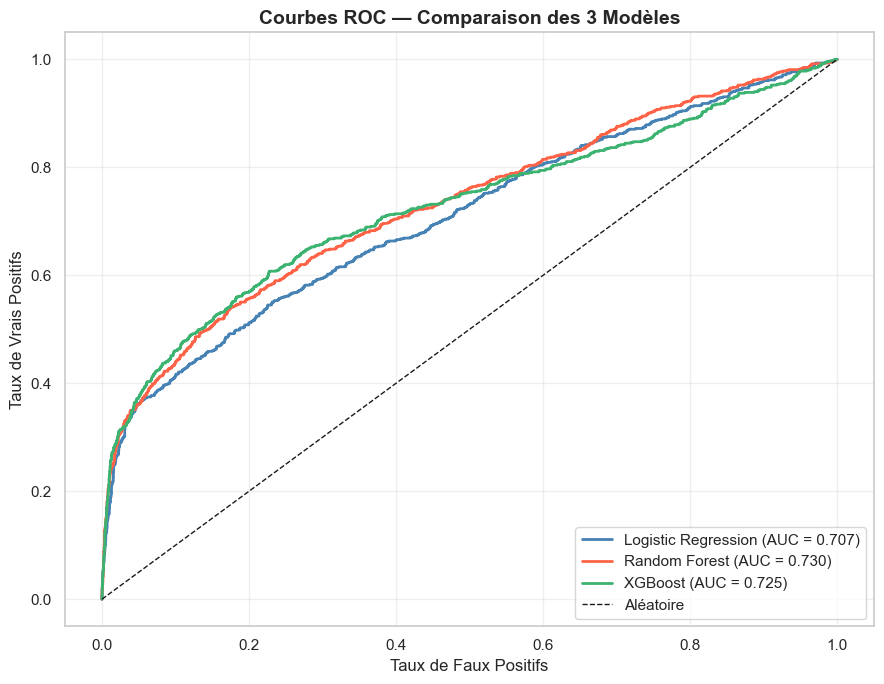

In [29]:
# ── 7. COURBES ROC COMPARATIVES ──────────────────────────────

plt.figure(figsize=(9, 7))
colors = ['steelblue', 'tomato', 'mediumseagreen']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--', lw=1, label='Aléatoire')
plt.xlabel('Taux de Faux Positifs'); plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC — Comparaison des 3 Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/phase4_roc_curves.png', dpi=150)
plt.show()

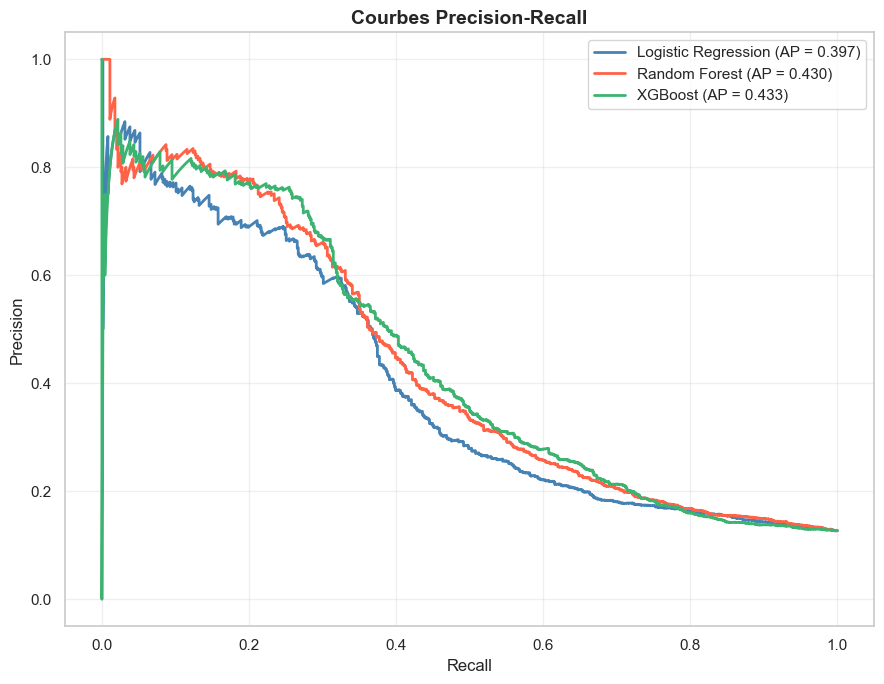

In [30]:
# ── 8. PRECISION-RECALL CURVES ───────────────────────────────

plt.figure(figsize=(9, 7))
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    plt.plot(rec, prec, lw=2, color=color, label=f"{name} (AP = {res['ap']:.3f})")

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Courbes Precision-Recall', fontsize=14, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/phase4_precision_recall.png', dpi=150)
plt.show()

Meilleur modèle : Random Forest  (AUC = 0.7298)


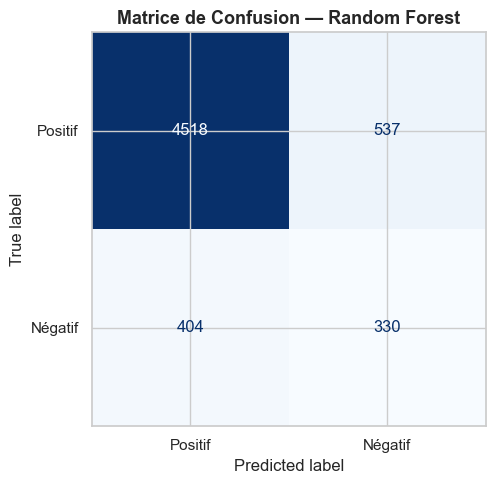

In [31]:
# ── 9. MATRICE DE CONFUSION — MEILLEUR MODÈLE ────────────────

best_name = max(results, key=lambda n: results[n]['auc'])
best      = results[best_name]
print(f"Meilleur modèle : {best_name}  (AUC = {best['auc']:.4f})")

cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Positif','Négatif'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Matrice de Confusion — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/phase4_confusion_matrix.png', dpi=150)
plt.show()

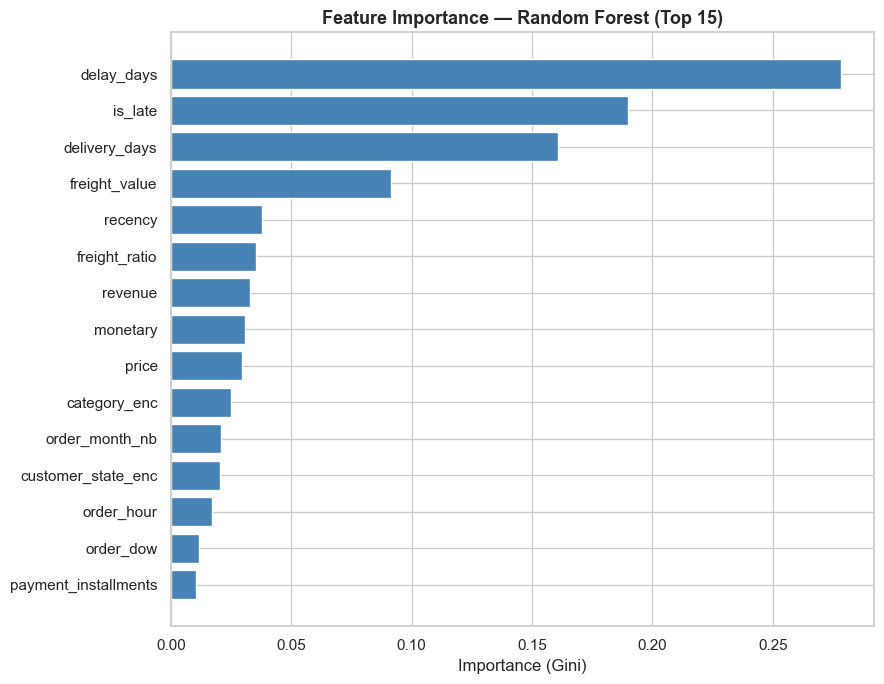

In [32]:
# ── 10. FEATURE IMPORTANCE (Random Forest) ──────────────────

rf_model = results['Random Forest']['model']
importances = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(9, 7))
plt.barh(importances['feature'], importances['importance'], color='steelblue')
plt.title('Feature Importance — Random Forest (Top 15)', fontsize=13, fontweight='bold')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.savefig('../reports/figures/phase4_feature_importance.png', dpi=150)
plt.show()

In [33]:
# ── 11. SHAP VALUES — INTERPRÉTABILITÉ ──────────────────────

print("Calcul des SHAP values (peut prendre 1-2 min)...")

# On prend XGBoost ou RF selon le meilleur modèle
if best_name == 'XGBoost':
    explainer = shap.TreeExplainer(best['model'])
else:
    explainer = shap.TreeExplainer(results['Random Forest']['model'])

# Échantillon pour la vitesse
X_sample = X_test.sample(min(1500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Pour les classifieurs binaires RF, shap_values est une liste [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

Calcul des SHAP values (peut prendre 1-2 min)...


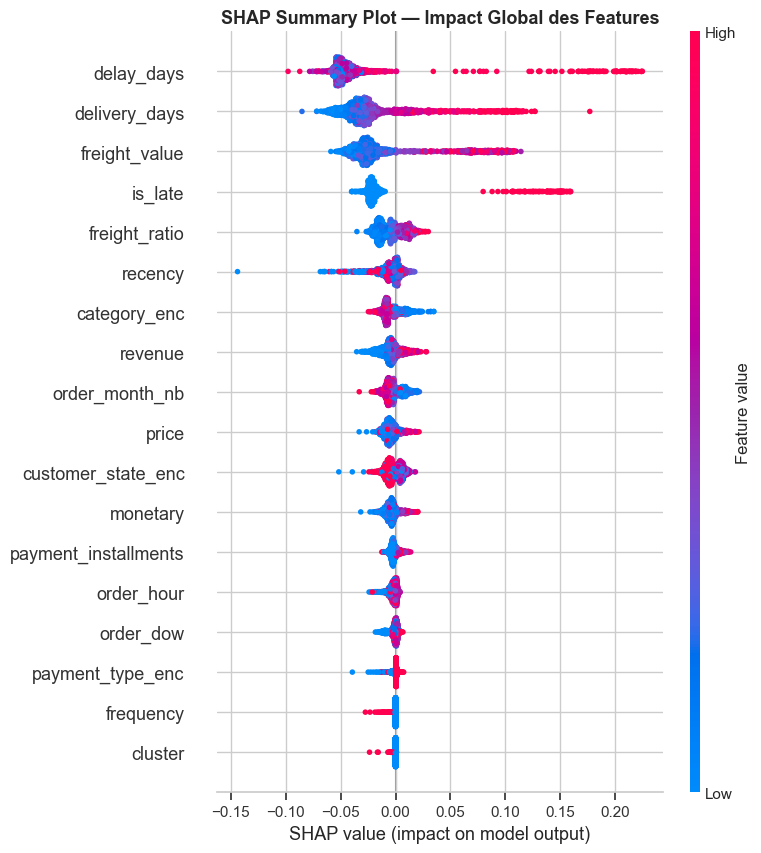

In [34]:
# 11.1 SHAP Summary Plot (Global)
plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, feature_names=FEATURES, show=False)
plt.title("SHAP Summary Plot — Impact Global des Features", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/phase4_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

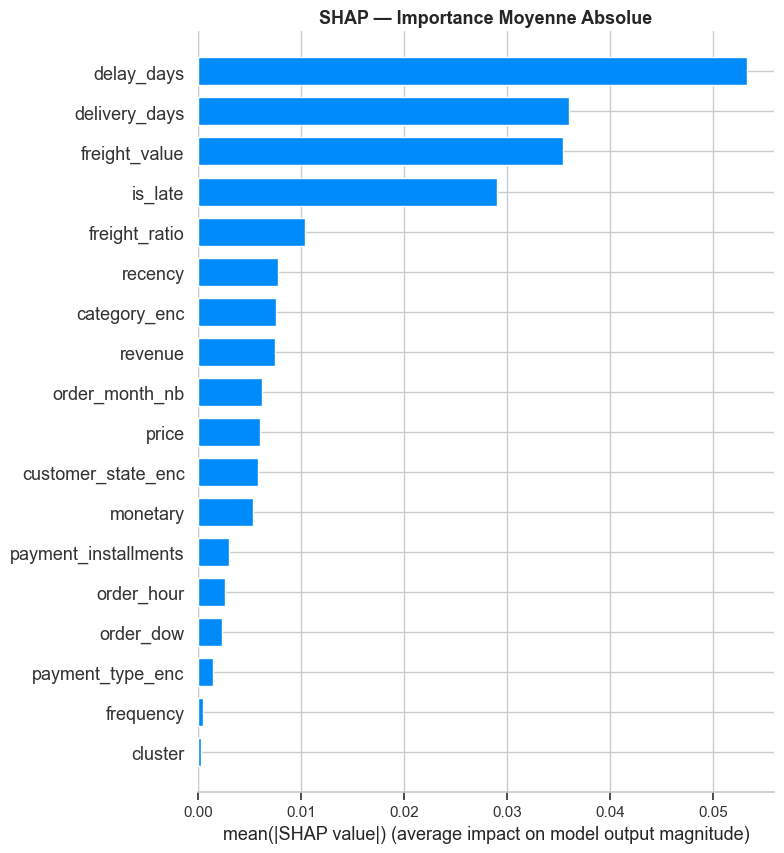

In [35]:
# 11.2 SHAP Bar Plot (importance moyenne absolue)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title("SHAP — Importance Moyenne Absolue", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/phase4_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


Explication locale — observation #0
Vraie valeur      : 0
Expected value    : 0.5000


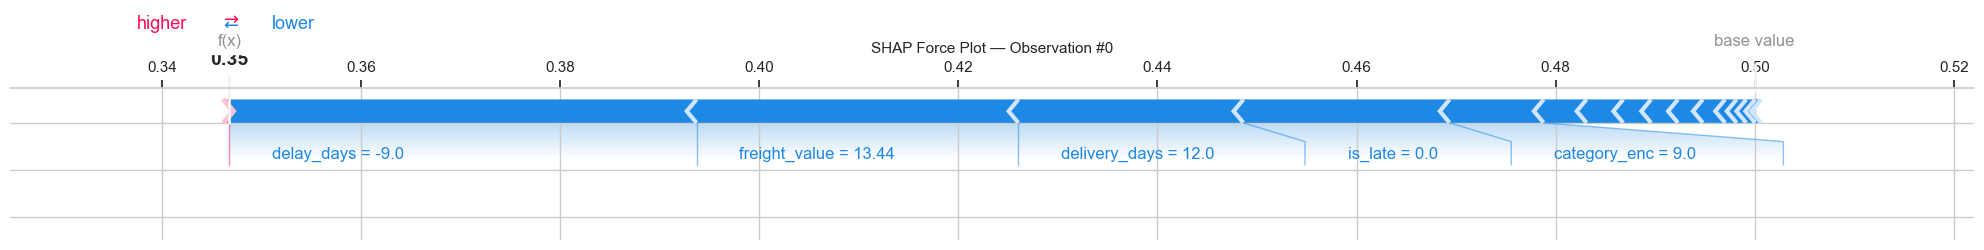

In [36]:
# 11.3 SHAP Force Plot — Explication locale (1 prédiction)
idx = 0

print(f"\nExplication locale — observation #{idx}")
print(f"Vraie valeur      : {y_test.iloc[idx]}")

# ✅ Récupérer correctement expected_value selon le type de modèle
expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = float(expected_val[1])  # classe 1 (avis négatif)
else:
    expected_val = float(expected_val)

# ✅ Récupérer les shap values de la bonne observation
shap_val_idx = sv[idx] if sv.ndim == 2 else sv

print(f"Expected value    : {expected_val:.4f}")

shap.force_plot(
    expected_val,
    shap_val_idx,
    X_sample.iloc[idx],
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)

plt.title(f"SHAP Force Plot — Observation #{idx}", fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/phase4_shap_force_local.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 900x600 with 0 Axes>

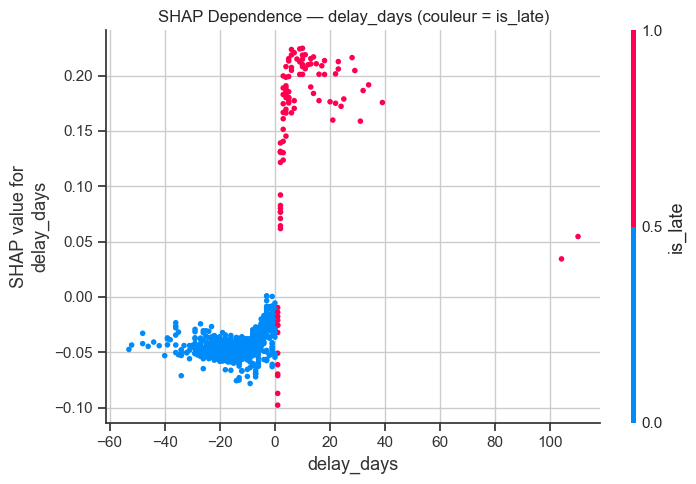

In [37]:
# 11.4 SHAP Dependence Plot — delay_days (feature clé)
plt.figure(figsize=(9, 6))
shap.dependence_plot('delay_days', sv, X_sample,
                     feature_names=FEATURES, interaction_index='is_late', show=False)
plt.title("SHAP Dependence — delay_days (couleur = is_late)", fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/phase4_shap_dependence.png', dpi=150)
plt.show()

In [38]:
# ── 12. TABLEAU COMPARATIF FINAL ─────────────────────────────

summary = pd.DataFrame({
    'Modèle': list(results.keys()),
    'AUC-ROC': [results[n]['auc'] for n in results],
    'Avg Precision': [results[n]['ap'] for n in results],
    'CV AUC (mean)': [cv_results[n].mean() for n in results],
    'CV AUC (std)':  [cv_results[n].std()  for n in results],
}).set_index('Modèle').round(4)

print("\n", "="*55)
print("TABLEAU COMPARATIF — PERFORMANCE DES MODÈLES")
print("="*55)
print(summary.to_string())

summary.to_csv('../reports/phase4_model_comparison.csv')
print("\n✅ Sauvegardé → reports/phase4_model_comparison.csv")


TABLEAU COMPARATIF — PERFORMANCE DES MODÈLES
                     AUC-ROC  Avg Precision  CV AUC (mean)  CV AUC (std)
Modèle                                                                  
Logistic Regression   0.7071         0.3972         0.7126        0.0047
Random Forest         0.7298         0.4296         0.7186        0.0055
XGBoost               0.7252         0.4333         0.7142        0.0035

✅ Sauvegardé → reports/phase4_model_comparison.csv


In [39]:
# ── 13. SAUVEGARDE DU MEILLEUR MODÈLE ───────────────────────

import joblib, os
os.makedirs('../models', exist_ok=True)

best_model_obj = results[best_name]['model']
joblib.dump(best_model_obj, f'../models/best_model_{best_name.replace(" ","_").lower()}.pkl')
print(f"✅ Meilleur modèle sauvegardé : models/best_model_{best_name.replace(' ','_').lower()}.pkl")

✅ Meilleur modèle sauvegardé : models/best_model_random_forest.pkl


In [40]:
# ── 14. RÉSUMÉ EXÉCUTIF PHASE 4 ─────────────────────────────

print("""
╔══════════════════════════════════════════════════════════╗
║           RÉSUMÉ — PHASE 4 MODÉLISATION                  ║
╠══════════════════════════════════════════════════════════╣
║  Problème   : Classification binaire (avis négatif ≤ 2)  ║
║  3 modèles  : Logistic Regression, Random Forest, XGB    ║
║  Meilleur   : {:<38s}║
║  AUC-ROC    : {:<38s}║
║  Top features (SHAP) :                                   ║
║    1. delay_days    — retard de livraison                ║
║    2. delivery_days — durée totale de livraison          ║
║    3. freight_ratio — rapport frais port/prix            ║
║    4. monetary      — valeur client RFM                  ║
║  → Prêt pour Phase 5 (Dashboard) & Phase 6 (A/B Test)   ║
╚══════════════════════════════════════════════════════════╝
""".format(best_name, f"{best['auc']:.4f}"))


╔══════════════════════════════════════════════════════════╗
║           RÉSUMÉ — PHASE 4 MODÉLISATION                  ║
╠══════════════════════════════════════════════════════════╣
║  Problème   : Classification binaire (avis négatif ≤ 2)  ║
║  3 modèles  : Logistic Regression, Random Forest, XGB    ║
║  Meilleur   : Random Forest                         ║
║  AUC-ROC    : 0.7298                                ║
║  Top features (SHAP) :                                   ║
║    1. delay_days    — retard de livraison                ║
║    2. delivery_days — durée totale de livraison          ║
║    3. freight_ratio — rapport frais port/prix            ║
║    4. monetary      — valeur client RFM                  ║
║  → Prêt pour Phase 5 (Dashboard) & Phase 6 (A/B Test)   ║
╚══════════════════════════════════════════════════════════╝

